In [1]:
import tomopy
import numpy as np
import matplotlib.pyplot as plt

Create 3D ndarray of zeros and ones

In [7]:
# # Create coordinate grids for dims 0 and 2
# x = np.linspace(0, 2 * np.pi, 100)  # dim 0
# z = np.linspace(0, 2 * np.pi, 80)   # dim 2

# # Build 2D structure in (dim0, dim2) plane, broadcast across dim1
# X, Z = np.meshgrid(x, z, indexing='ij')  # shape (100, 80)
# structure = np.sin(X) + 0.5 * np.cos(2 * Z) + np.sin(X + Z)

# # Broadcast to (100, 50, 80) — uniform along dim 1
# arr = np.broadcast_to(structure[:, np.newaxis, :], (100, 50, 80)).copy()

# # Optional: add small noise so dim1 isn't perfectly flat
# # arr += 0.05 * np.random.randn(100, 50, 80)

# print(arr.shape)   # (100, 50, 80)
# print(arr.min(), arr.max())

(50, 100, 80)
[0 1]


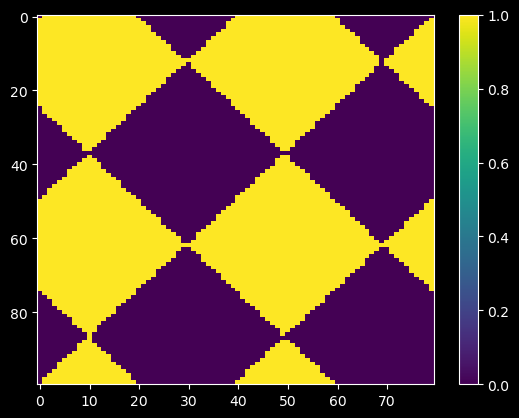

In [12]:
# Binary structure in (dim0, dim2) plane
x = np.linspace(0, 4 * np.pi, 100)  # dim 0
z = np.linspace(0, 4 * np.pi, 80)   # dim 2

X, Z = np.meshgrid(x, z, indexing='ij')  # shape (100, 80)

# Binary mask: 1 where combined sinusoid is positive, else 0
structure = ((np.sin(X) + np.sin(Z)) > 0).astype(np.uint8)  # shape (100, 80)

# Repeat along dim 1: tile 50 times → (50, 100, 80)
arr = np.repeat(structure[np.newaxis, :, :], 50, axis=0)

print(arr.shape)        # (50, 100, 80)
print(np.unique(arr))   # [0 1]

plt.imshow(arr[25, :, :], aspect='auto')  # Show slice at middle of dim1
plt.colorbar()

## Gaussian blur in the wrong direction

In [13]:
arr_gauss = tomopy.misc.corr.gaussian_filter(arr, sigma=5, order=0, axis=1)

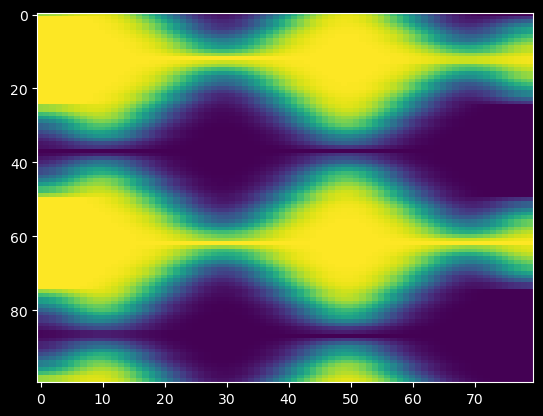

In [14]:
plt.imshow(arr_gauss[25, :, :], aspect='auto')  # Show slice at middle of dim1

## Gaussian blur in the correct direction

In [16]:
arr_gauss = tomopy.misc.corr.gaussian_filter(arr, sigma=5, order=0, axis=0)

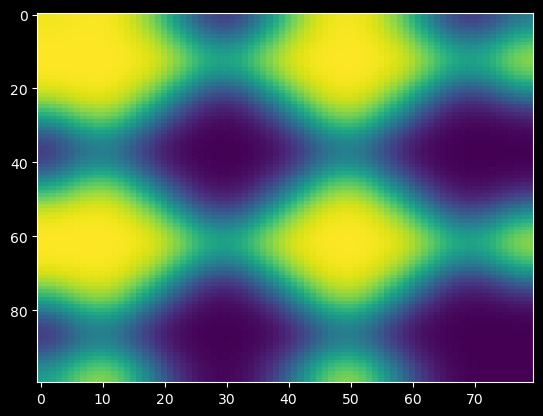

In [17]:
plt.imshow(arr_gauss[25, :, :], aspect='auto')  # Show slice at middle of dim1